In [ ]:
import pandas as pd
import numpy as np

path=r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\data\proceessed\mahanadi_10k_2.csv"
df = pd.read_csv(path)
df.head()

,easting,northing,point_id,distance_to_river,aspect,dem,flow_accumulation,twi,slope,flood,rainfall,drainage_density,ext_rainfall,lulc,soil
0,4.440315e+06,3.795031e+06,0,7.821066,226.678772,312.250397,14827.771484,0.003432,36.852150,0,0.007934,30,1446.716749,89.992218,32
1,4.365226e+06,3.620098e+06,1,8.324021,80.900414,165.639252,1063.202759,0.004834,33.286972,0,0.008018,10,1677.948131,89.997490,32
2,4.405376e+06,3.703322e+06,2,7.059326,309.435669,314.583435,6852.160156,0.010368,43.976154,0,0.023937,10,1747.072188,89.996101,31
3,4.126099e+06,3.801462e+06,3,9.429493,228.493988,379.034485,14943.403320,0.006487,33.583542,0,0.007927,40,2416.565764,89.942177,38
4,4.263027e+06,3.660885e+06,4,9.975600,29.364761,336.658630,60400.003906,0.019009,33.866005,0,0.007998,40,1732.596941,89.982491,25


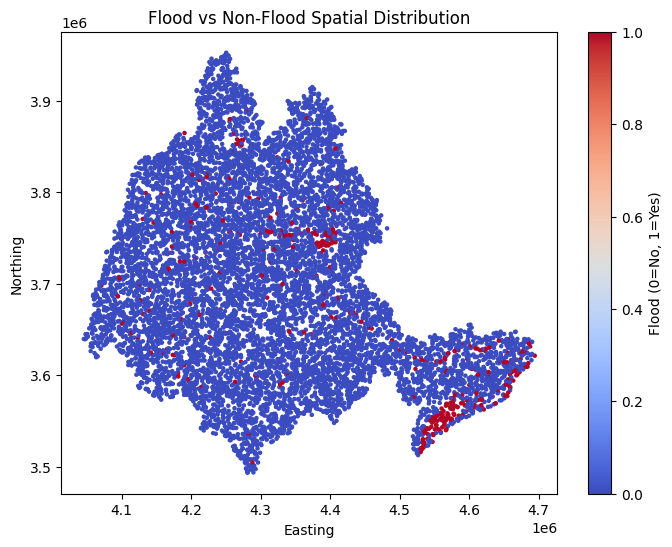

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["easting"],
    df["northing"],
    c=df["flood"],
    cmap="coolwarm",
    s=5
)

plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Flood vs Non-Flood Spatial Distribution")

plt.colorbar(label="Flood (0=No, 1=Yes)")

plt.show()

In [10]:
# Feature division
X = df.drop(['flood',"point_id", "easting", "northing"], axis=1)
y = df['flood']
X.columns

Index(['distance_to_river', 'aspect', 'dem', 'flow_accumulation', 'twi',
       'slope', 'rainfall', 'drainage_density', 'ext_rainfall', 'lulc',
       'soil'],
      dtype='object')

In [11]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [12]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (7000, 11)
Test set: (3000, 11)


In [14]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

# CatBoost model
cat_model = CatBoostClassifier(verbose=0)

# Hyperparameter grid
param_grid_cat = {
    "iterations": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "depth": [4, 6, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7],
    "border_count": [32, 64, 128],
    "scale_pos_weight": [1, 5, 10]
}

In [15]:
# Grid Search
grid_cat = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid_cat,
    cv=5,
    scoring="f1",
    verbose=2,
    n_jobs=-1
)

In [40]:
# Fit
import warnings
warnings.filterwarnings('ignore')

grid_cat.fit(X_train, y_train)

# Best results
print("Best Params:", grid_cat.best_params_)
print("Best Score:", grid_cat.best_score_)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
[CV] END border_count=32, depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.01, scale_pos_weight=1; total time=   0.8s
[CV] END border_count=32, depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.01, scale_pos_weight=5; total time=   0.6s
[CV] END border_count=32, depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.01, scale_pos_weight=10; total time=   0.6s
[CV] END border_count=32, depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.01, scale_pos_weight=10; total time=   0.3s
[CV] END border_count=32, depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.1, scale_pos_weight=1; total time=   0.4s
[CV] END border_count=32, depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.1, scale_pos_weight=5; total time=   0.3s
[CV] END border_count=32, depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.1, scale_pos_weight=5; total time=   0.3s
[CV] END border_count=32, depth=4, iterations=100, l2_leaf_re

In [ ]:
# # Evaluate on test set
# best_cat = grid_cat.best_estimator_
# y_pred_cat = best_cat.predict(X_test)
# y_pred_proba_cat = best_cat.predict_proba(X_test)[:, 1]

In [ ]:
# # Save the best model found by GridSearchCV
# import joblib

# joblib.dump(grid_cat.best_estimator_, '/kaggle/working/.virtual_documents/best_cat_model.pkl')

# print("Trained model saved as 'best_cat_model.pkl'")

Trained model saved as 'best_cat_model.pkl'


In [ ]:
# print("Best Params:", grid_cat.best_params_)
# # print("Best Score:", grid_cat.best_score_)

Best Params: {'border_count': 128, 'depth': 4, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1, 'scale_pos_weight': 5}
Best Score: 0.7488827566589322


In [16]:
# Load the trained model
import joblib

cat_model_path = r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\catboost\best_cat_model.pkl"
model = joblib.load(cat_model_path)

# use it
best_cat = model
print(model.get_params())

{'verbose': 0, 'border_count': 64, 'depth': 4, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.2, 'scale_pos_weight': 1}


In [17]:
y_pred_cat = best_cat.predict(X_test)
y_pred_proba_cat = best_cat.predict_proba(X_test)[:, 1]

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score,accuracy_score, roc_curve, confusion_matrix
precision = precision_score(y_test, y_pred_cat)
recall = recall_score(y_test, y_pred_cat)
acc = accuracy_score(y_test, y_pred_cat)
f1 = f1_score(y_test, y_pred_cat)
roc_auc = roc_auc_score(y_test, y_pred_proba_cat)
cm = confusion_matrix(y_test, y_pred_cat)

print("\nTest Set Performance:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Confusion Matrix:\n{cm}")


Test Set Performance:
Precision: 0.8900
Recall: 0.7120
F1 Score: 0.7911
Accuracy: 0.9843
ROC AUC: 0.9516
Confusion Matrix:
[[2864   11]
 [  36   89]]


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))

[[2864   11]
 [  36   89]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2875
           1       0.89      0.71      0.79       125

    accuracy                           0.98      3000
   macro avg       0.94      0.85      0.89      3000
weighted avg       0.98      0.98      0.98      3000



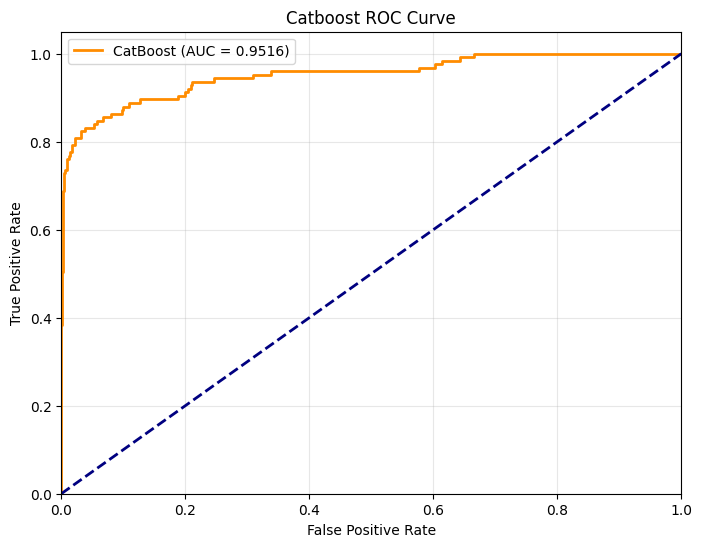

In [20]:
#  Plot ROC curve

import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_cat)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'CatBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Catboost ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Top 10 Features:
          feature  importance
              dem   13.984012
distance_to_river   12.106960
flow_accumulation   10.450456
            slope   10.275518
             lulc   10.219820
 drainage_density    9.653669
           aspect    9.297827
              twi    6.384564
             soil    6.352590
         rainfall    5.770644


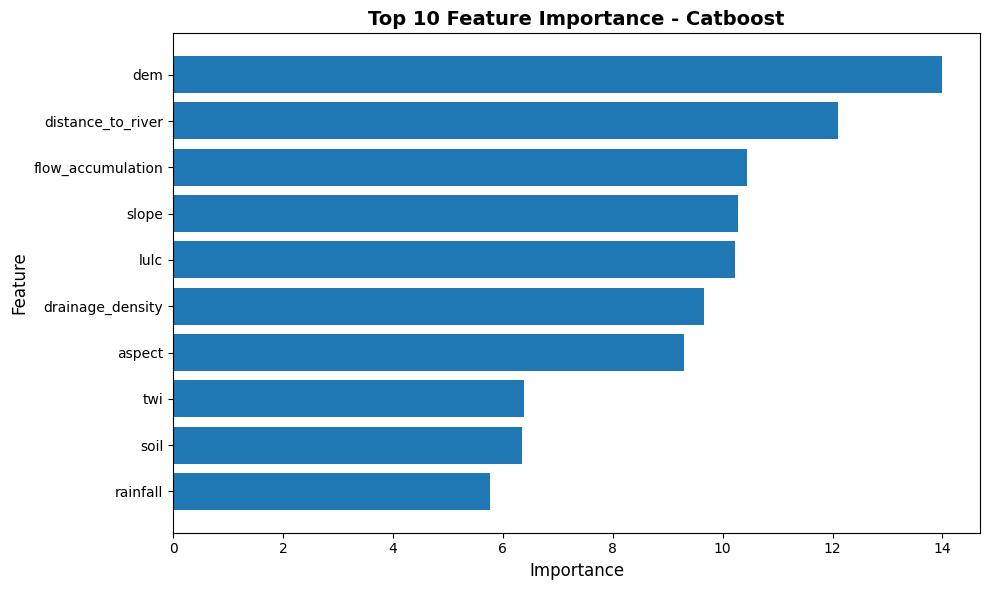

Feature importance plot displayed


In [26]:
feature_importance = (
        pd.DataFrame({"feature": X.columns, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(10)
    )

print("\nTop 10 Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance["importance"])
plt.yticks(range(len(feature_importance)), feature_importance["feature"])
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 10 Feature Importance - Catboost", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Feature importance plot displayed")

c:\Users\ps302\OneDrive\Desktop\Hydrology\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


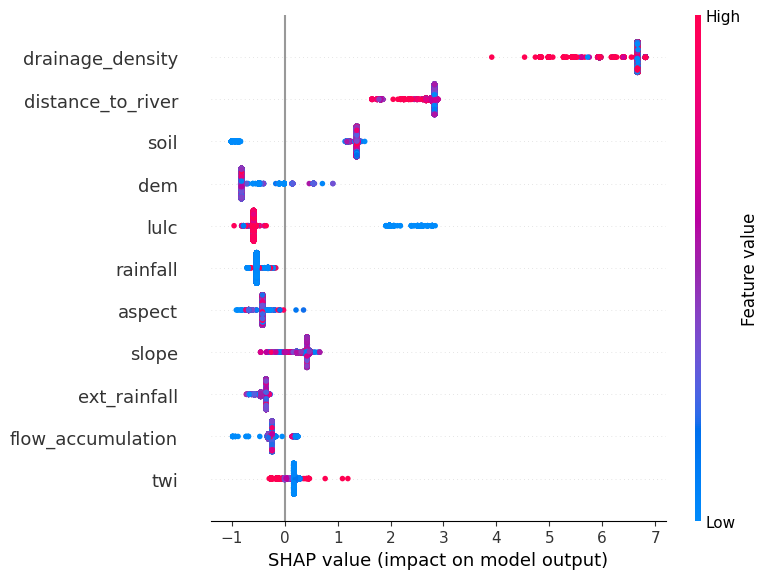

In [22]:
import shap
import matplotlib.pyplot as plt

# Create explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X)